### 1. Setup and Imports

In [41]:

%load_ext autoreload
%autoreload 2

import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Add the src directory to system path to import modules
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

from preprocessor import ComplaintProcessor

# Path configuration
RAW_DATA_PATH = '../data/raw/complaints.csv' 
PROCESSED_DATA_PATH = '../data/processed/filtered_complaints.csv'


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 2. Load Data and Initial Stats

In [13]:
# Initialize the processor
processor = ComplaintProcessor(RAW_DATA_PATH)

# Load Data
df = processor.load_data()

# Get Basic Stats (Task: Identify complaints with/without narratives)
stats = processor.get_basic_stats()
print("=== Dataset Statistics ===")
print(f"Total Complaints: {stats['Total Rows']}")
print(f"Complaints with Narrative: {stats['Present Narratives']}")
print(f"Complaints without Narrative: {stats['Missing Narratives']}")

Loading data from ../data/raw/complaints.csv...


e:\DS_Courses\KAIM_10_Academy\KAIM_8\Week_7\KAIM_Week7\src\preprocessor.py:35: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  self.df = pd.read_csv(self.file_path)


Data loaded successfully. Shape: (9609797, 18)
=== Dataset Statistics ===
Total Complaints: 9609797
Complaints with Narrative: 2980756
Complaints without Narrative: 6629041


Product Distribution (Task: Analyze distribution across Products)

In [42]:
# check unique products
unique_products = df['Product'].unique()
print(unique_products)

['Credit reporting or other personal consumer reports' 'Debt collection'
 'Credit card' 'Checking or savings account'
 'Money transfer, virtual currency, or money service'
 'Vehicle loan or lease' 'Debt or credit management' 'Mortgage'
 'Payday loan, title loan, personal loan, or advance loan' 'Prepaid card'
 'Student loan' 'Credit reporting'
 'Credit reporting, credit repair services, or other personal consumer reports'
 'Credit card or prepaid card' 'Payday loan, title loan, or personal loan'
 'Bank account or service' 'Money transfers' 'Consumer Loan' 'Payday loan'
 'Other financial service' 'Virtual currency']


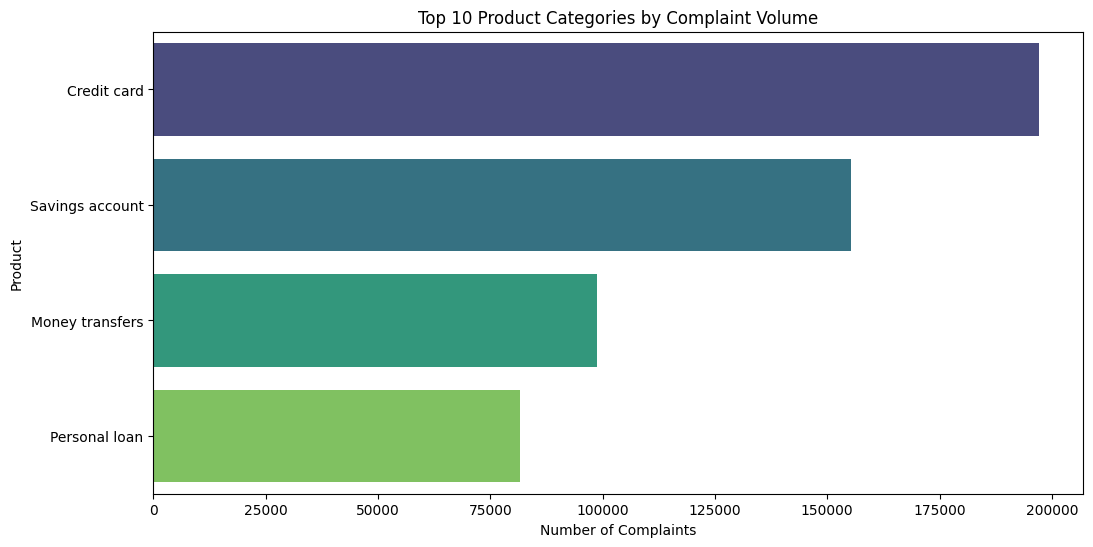

In [49]:
# Visualize initial distribution
processor.plot_product_distribution()

### 3. Filtering

In [45]:
# 1. Initialize
from preprocessor import ComplaintProcessor
processor = ComplaintProcessor('../data/raw/complaints.csv')

# 2. Process in chunks (Solves MemoryError)
df_filtered = processor.process_and_filter(chunk_size=100000)

Starting chunked processing (Size: 100000)...
Processed 500000 rows...
Processed 1000000 rows...
Processed 1500000 rows...
Processed 2000000 rows...
Processed 2500000 rows...
Processed 3000000 rows...
Processed 3500000 rows...
Processed 4000000 rows...
Processed 4500000 rows...
Processed 5000000 rows...
Processed 5500000 rows...
Processed 6000000 rows...
Processed 6500000 rows...
Processed 7000000 rows...
Processed 7500000 rows...
Processed 8000000 rows...
Processed 8500000 rows...
Processed 9000000 rows...
Processed 9500000 rows...
Finished! Final dataset size: 532669 rows.


In [46]:
# Check the results
print(df_filtered['Product'].value_counts())

Product
Credit card        197126
Savings account    155204
Money transfers     98685
Personal loan       81654
Name: count, dtype: int64


### 4. Text Cleaning and Length Analysis

Cleaning text narratives (this may take a moment)...
Text cleaning complete.


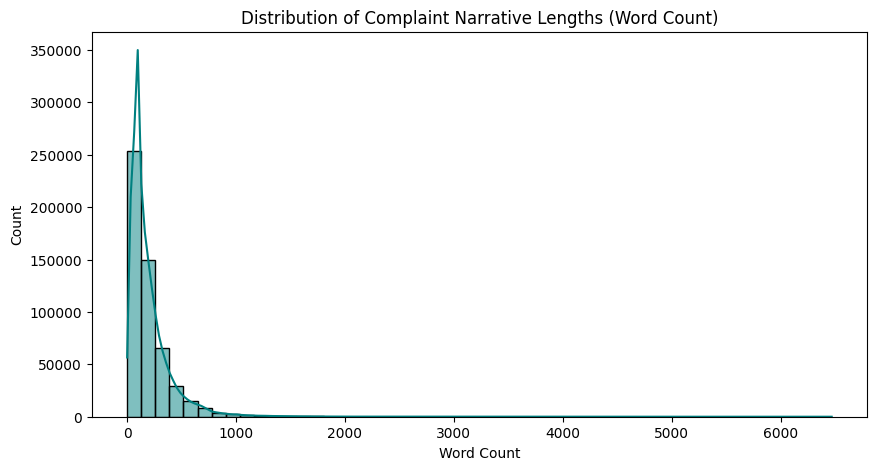

count    532669.000000
mean        203.611053
std         219.749160
min           1.000000
25%          82.000000
50%         139.000000
75%         254.000000
max        6469.000000
Name: word_count, dtype: float64


In [47]:
# 3. Clean text 
processor.preprocess_narratives()

# Analyze and plot word counts
processor.analyze_narrative_length()

Save Output

In [48]:
# 4. Save the final dataset
processor.save_processed_data(PROCESSED_DATA_PATH)

Processed data saved to ../data/processed/filtered_complaints.csv
